# MLOps in Practice:

**Audience:** Faculty & undergraduate students  |  **Runtime:** ~8–10 min on a free Colab GPU

> ⚙️ **Before you start:** Go to `Runtime → Change runtime type → T4 GPU`, then `Runtime → Run all` (or run cells one by one as we discuss them).

---

## 🎯 What this notebook teaches

Most ML courses end at *"the model reached 99% accuracy."* Industry starts there. **MLOps** is everything needed to make a model *reproducible, trackable, testable, deployable, and monitorable*.

| # | Section | MLOps concept | Tool used here | Industry equivalent |
|---|---------|---------------|----------------|---------------------|
| 1 | The naive notebook | Why MLOps exists | — | — |
| 2 | Reproducibility | Seeds & configs | Python config dict | Hydra / YAML configs |
| 3 | Experiment tracking | Compare runs scientifically | **MLflow Tracking** | MLflow / W&B / Neptune |
| 4 | Model registry | Versioned, governed models | **MLflow Registry** | MLflow / SageMaker Registry |
| 5 | Validation gates | "CI/CD for models" | pytest-style checks | GitHub Actions + tests |
| 6 | Serving | Model behind an interface | **Gradio** demo app | FastAPI + Docker + K8s |
| 7 | Monitoring & drift | Models decay in production | Simulated drift + MLflow | Evidently AI / Arize |
| 8 | The full lifecycle | Putting it together | Recap diagram | — |

**Stack:** 100% open-source — PyTorch, MLflow, Gradio, torchvision.

> 💡 *Why not LangChain?* LangChain is a framework for chaining **LLM** calls (prompts, agents, RAG). For a CNN training pipeline it adds complexity without benefit, so we deliberately leave it out — choosing the *right* tool is itself an MLOps lesson.


## ⚙️ Setup (≈1 min)
PyTorch and torchvision are pre-installed on Colab; we only add MLflow (tracking + registry) and Gradio (serving demo).

In [2]:
!wget https://raw.githubusercontent.com/kumarsirish/FDP-MLOPS/main/requirements.txt
# Install the MLOps tooling from requirements.txt
%pip install -r requirements.txt

import os
import torch, torchvision, mlflow
from dotenv import load_dotenv

print("torch:", torch.__version__, "| torchvision:", torchvision.__version__, "| mlflow:", mlflow.__version__)
print("GPU available:", torch.cuda.is_available())

#load_dotenv()
#HF_TOKEN = userdata.get('HF_TOKEN')
#HF_TOKEN = os.getenv('HF_TOKEN')  # optional — only needed if pushing to Hugging Face Hub

--2026-06-14 09:51:56--  https://raw.githubusercontent.com/kumarsirish/FDP-MLOPS/main/requirements.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 70 [text/plain]
Saving to: ‘requirements.txt’

requirements.txt    100%[===================>]      70  --.-KB/s    in 0s      

2026-06-14 09:51:56 (2.40 MB/s) - ‘requirements.txt’ saved [70/70]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 130.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [3]:
# Load MNIST and create dataloaders (shared by every section below)
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# transform pipeline, convert the image to tensors and
# Normalizes the tensor images with the mean (0.1307) and standard deviation (0.3081) of the MNIST dataset.
# This helps in stabilizing and speeding up the training process.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),   # MNIST mean/std
])

#The MNIST training and test datasets are loaded from the `./data` directory
# Apply transform pipeline to it.
train_ds = datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2)

print(f"Number of images in training dataset: {len(train_ds):,}")
print(f"Number of images in test dataset: {len(test_ds):,}")
print(f"{len(train_ds):,} train | {len(test_ds):,} test | device: {DEVICE}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.34MB/s]


Number of images in training dataset: 60,000
Number of images in test dataset: 10,000
60,000 train | 10,000 test | device: cuda


---
# Part 1 — The "naive" student notebook 🚫

This is how models are *usually* trained in coursework: hardcoded hyperparameters, no logging, nothing saved. **Run it — it works!** Then we'll see why it fails in the real world.

In [4]:
# A deliberately tiny CNN so the whole demo fits in ~10 minutes
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            # It takes the greyscale input -1
            # looks for 16 patterns using 3x3 pixel filter
            # This reduces the image size by half (from 28x28 to 14x14).
            # It keeps only the most important information from each 3x3 pixel area.
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28→14
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14→7
            #2D to 1D conversion
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64), nn.ReLU(),
            #This is the final output layer.
            #Since MNIST has 10 digits (0 through 9), we need exactly 10 output scores.
            nn.Linear(64, 10),
        )
    def forward(self, x):
        return self.net(x)

# --- shared helpers (we reuse these in every later section) ---
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for x, y in loader: #x-> images, y-> labels
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad() # Resets the gradient
        loss = F.cross_entropy(model(x), y) # Calculates the loss
        loss.backward() # recalculates the weights
        optimizer.step() # updates the weights
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

#Runs the model on all data without training, counts correct predictions, and returns the accuracy as a fraction.
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        correct += (model(x).argmax(dim=1) == y).sum().item()
    return correct / len(loader.dataset)

# --- the "naive" training run: everything hardcoded, nothing recorded ---
model = SmallCNN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)   # magic number!
loss = train_one_epoch(model, train_loader, optimizer)
acc = evaluate(model, test_loader)
print(f"loss={loss:.4f}  test_accuracy={acc:.4f}  ✅ ...and now what?")

loss=0.3728  test_accuracy=0.9688  ✅ ...and now what?


### 🤔 Discussion: what just went wrong (even though it "worked")?

1. **Reproducibility** — run the cell again. Do you get the *same* accuracy? (No — random init & shuffling.)
2. **Memory** — you try `lr=0.005` tomorrow. Which run was better? Where is yesterday's number?
3. **The model is gone** — close this notebook and the trained weights vanish. Nothing was saved or versioned.
4. **No quality bar** — would you ship this to a hospital or a bank with zero automated checks?
5. **No serving / monitoring** — a model inside a notebook helps no one; and even deployed models *decay* as the world changes.

The rest of the notebook fixes these problems **one by one**.

---
# Part 2 — Reproducibility: seeds + configuration ✅

**Rule 1 of MLOps:** If you can't run it twice and get the same result, it didn't happen.
Two cheap habits fix most of it: **fix randomness** and **move magic numbers into a config object** (in real projects: a YAML file managed by tools like Hydra).

In [5]:
import random
import numpy as np

def set_seed(seed: int):
    """Fix every source of randomness we control."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# One single source of truth — no magic numbers scattered through the code.
CONFIG = {
    "model":      "SmallCNN",
    "lr":         0.001,
    "epochs":     2,
    "batch_size": 256,
    "optimizer":  "Adam",
    "seed":       42,
}


> 🧪 **Mini-exercise:** wrap the naive training from Part 1 with `set_seed(42)` and run it twice — the numbers now match.
>
> 👩‍🏫 *For faculty:* full bit-wise determinism on GPU also needs `torch.use_deterministic_algorithms(True)` and pinned library versions (`requirements.txt` / Docker) — a great seminar topic on its own.

---
# Part 3 — Experiment tracking with MLflow 📊

Instead of memory, sticky notes, or `results_final_v2_REAL.txt`, every run now records its **parameters, metrics per epoch, and the trained model artifact** into MLflow. We run a small **learning-rate sweep** — exactly how teams pick hyperparameters in practice.

In [6]:
import time
import mlflow.pytorch
import os

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri("file:./mlruns")          # local folder; in industry: a tracking server
mlflow.set_experiment("mnist-cnn-mlops")

def run_experiment(config: dict):
    """One fully-tracked training run."""
    set_seed(config["seed"])
    model = SmallCNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    with mlflow.start_run(run_name=f"lr={config['lr']}") as run:
        mlflow.log_params(config)                                  # 1) what we tried
        for epoch in range(config["epochs"]):
            t0 = time.time()
            train_loss = train_one_epoch(model, train_loader, optimizer)
            val_acc = evaluate(model, test_loader)
            mlflow.log_metrics({                                   # 2) how it went
                "train_loss": train_loss,
                "val_accuracy": val_acc,
                "epoch_seconds": time.time() - t0,
            }, step=epoch)
            print(f"    epoch {epoch+1}/{config['epochs']}  loss={train_loss:.4f}  val_acc={val_acc:.4f}")
        try:                                                       # 3) the model itself
            mlflow.pytorch.log_model(model, name="model")
        except TypeError:  # older MLflow API
            mlflow.pytorch.log_model(model, "model")
        return run.info.run_id, val_acc

# --- the sweep: 3 runs × 2 epochs ≈ 2–3 min on a T4 GPU ---
# Run the experiments with various learning rates and compare their performances
for lr in [0.00005, 0.001, 0.005]:
    print(f"▶ Run with lr={lr}")
    run_experiment({**CONFIG, "lr": lr})

2026/06/14 09:53:20 INFO mlflow.tracking.fluent: Experiment with name 'mnist-cnn-mlops' does not exist. Creating a new experiment.


▶ Run with lr=5e-05
    epoch 1/2  loss=1.6502  val_acc=0.8235


2026/06/14 09:53:52 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


    epoch 2/2  loss=0.5788  val_acc=0.8946


2026/06/14 09:53:52 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/14 09:54:02 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


...

2026/06/14 09:54:34 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


▶ Run with lr=0.005
    epoch 1/2  loss=0.1802  val_acc=0.9794


2026/06/14 09:55:01 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/14 09:55:01 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


    epoch 2/2  loss=0.0472  val_acc=0.9870


2026/06/14 09:55:08 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


In [7]:
# Query the tracking store like a database — no more guessing which run was best
runs = mlflow.search_runs(experiment_names=["mnist-cnn-mlops"])
leaderboard = (
    runs[["run_id", "params.lr", "metrics.val_accuracy", "metrics.train_loss"]]
    .sort_values("metrics.val_accuracy", ascending=False)
    .reset_index(drop=True)
)
leaderboard

,run_id,params.lr,metrics.val_accuracy,metrics.train_loss
0,d41e3694aca6401e8cea3ed7b6ea0fb8,0.005,0.9870,0.047228
1,50b446342a6e4d488446fe66f12640ee,0.001,0.9837,0.082492
2,8068ac99cf0346a99ceaaa0b3c173dbd,5e-05,0.8946,0.578774


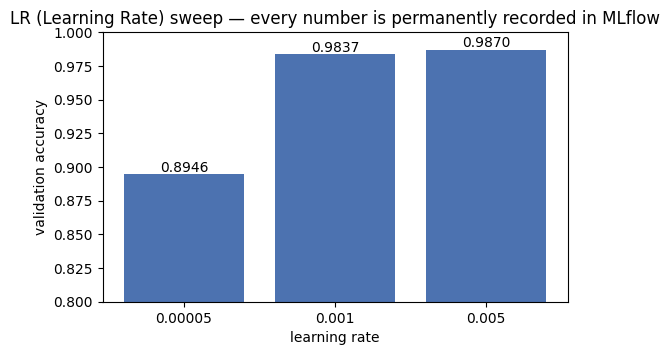

In [13]:
import matplotlib.pyplot as plt

lb = leaderboard.sort_values("params.lr", key=lambda s: s.astype(float))
# Replace '5e-05' with '0.00005' for better readability on the plot
lb["params.lr"] = lb["params.lr"].replace('5e-05', '0.00005')

plt.figure(figsize=(6, 3.5))
plt.bar(lb["params.lr"], lb["metrics.val_accuracy"], color="#4C72B0")
plt.ylim(0.8, 1.0)
plt.xlabel("learning rate"); plt.ylabel("validation accuracy")
plt.title("LR (Learning Rate) sweep — every number is permanently recorded in MLflow")
for x, v in zip(lb["params.lr"], lb["metrics.val_accuracy"]):
    plt.text(x, v + 0.002, f"{v:.4f}", ha="center")
plt.show()

### 🖥️ Optional: open the full MLflow web UI inside Colab
The same dashboard ML teams stare at all day — run charts, diffs between runs, artifacts. (Opens in a new browser tab; pop-ups must be allowed.)

In [16]:
import subprocess, time
subprocess.Popen(["mlflow", "ui", "--port", "5000", "--backend-store-uri", "file:./mlruns"])
time.sleep(5)
from google.colab import output
output.serve_kernel_port_as_window(5000)


Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

> 🧪 **Mini-exercise:** add `"epochs": 3` or a new lr (e.g. `1e-2`) to the sweep, rerun, and watch it appear in the leaderboard automatically.

---
# Part 4 — Model registry: versioned models with a lifecycle 🗃️

Tracking answers *"what did we try?"*. The **registry** answers *"which exact model is in production?"*. Every registered model gets a **version number** and can move through stages (staging → production → archived) — with a full audit trail of which run, code, and parameters produced it.

In [ ]:
# Promote the BEST run from the sweep into the registry
best = leaderboard.iloc[0]
print(f"Best run: lr={best['params.lr']}  val_acc={best['metrics.val_accuracy']:.4f}")

model_uri = f"runs:/{best['run_id']}/model"
registered = mlflow.register_model(model_uri, name="mnist-cnn")
print(f"✅ Registered 'mnist-cnn' as version {registered.version}")

In [ ]:
# Anyone on the team (or a deployment server) can now pull the model BY NAME + VERSION —
# no emailing .pt files around.
prod_model = mlflow.pytorch.load_model(f"models:/mnist-cnn/{registered.version}").to(DEVICE)
print("Reloaded from registry — test accuracy:", f"{evaluate(prod_model, test_loader):.4f}")

> 👩‍🏫 *For faculty:* the registry is also where **governance** lives — model cards, approvals, rollback to a previous version when a deployment goes wrong. The equivalent for *data* is **DVC** (git-style versioning of datasets), worth mentioning on a slide.

---
# Part 5 — Validation gates: CI/CD thinking for models 🚦

Software has unit tests; models need them too. Before any deployment, the candidate model must pass automated **gates**. In industry these run in a CI pipeline (e.g. GitHub Actions) on every new model version — here we run them inline.

In [ ]:
@torch.no_grad()
def gate_accuracy(model, threshold=0.95):
    acc = evaluate(model, test_loader)
    return acc >= threshold, f"accuracy {acc:.4f} (need ≥ {threshold})"

@torch.no_grad()
def gate_latency(model, max_ms=50.0, trials=100):
    x = torch.randn(1, 1, 28, 28, device=DEVICE)
    model.eval(); model(x)                       # warm-up
    t0 = time.time()
    for _ in range(trials):
        model(x)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    ms = (time.time() - t0) / trials * 1000
    return ms <= max_ms, f"latency {ms:.2f} ms/image (need ≤ {max_ms} ms)"

@torch.no_grad()
def gate_sanity(model, n=8, min_correct=6):
    """Spot-check known examples — catches broken preprocessing & label-mapping bugs."""
    xs = torch.stack([test_ds[i][0] for i in range(n)]).to(DEVICE)
    ys = torch.tensor([test_ds[i][1] for i in range(n)], device=DEVICE)
    correct = (model(xs).argmax(dim=1) == ys).sum().item()
    return correct >= min_correct, f"{correct}/{n} known digits classified correctly"

def gate_size(model, max_mb=10.0):
    mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
    return mb <= max_mb, f"model size {mb:.2f} MB (need ≤ {max_mb} MB)"

# --- run the gate suite against the registry model ---
gates = {"Accuracy": gate_accuracy, "Latency": gate_latency,
         "Sanity check": gate_sanity, "Model size": gate_size}

all_pass = True
print("VALIDATION REPORT — mnist-cnn v" + str(registered.version))
print("-" * 55)
for name, fn in gates.items():
    ok, detail = fn(prod_model)
    all_pass &= ok
    print(f"{'✅' if ok else '❌'}  {name:<14} {detail}")
print("-" * 55)
print("🚀 MODEL APPROVED FOR DEPLOYMENT" if all_pass else "⛔ DEPLOYMENT BLOCKED — fix and re-run")

> 🧪 **Mini-exercise:** raise the accuracy threshold to `0.999` and watch the pipeline (correctly!) refuse to deploy. Automated *refusal* is the whole point of a gate.

---

---
# Part 6 — Serving: the model meets the world 🌍

A model in a notebook helps nobody. We now serve **the exact model pulled from the registry** behind an interactive app. **Draw a digit (0–9)** and watch live predictions.

*In production this would be FastAPI + Docker + Kubernetes; Gradio gives us the same idea in 15 lines — and it even generates a temporary public URL you can open on your phone.*

In [ ]:
import gradio as gr
import numpy as np
from PIL import Image

prod_model.eval()

def to_mnist_tensor(img):
    """Robustly convert a sketchpad/upload image into a normalized 1×1×28×28 tensor."""
    if isinstance(img, dict):                       # newer Gradio sketchpad returns a dict
        img = img.get("composite") if img.get("composite") is not None else img.get("image")
    arr = np.array(img)
    if arr.ndim == 3 and arr.shape[-1] == 4:        # RGBA from the sketchpad
        alpha = arr[..., 3].astype("float32")
        gray = alpha if alpha.max() > 0 else 255 - np.array(Image.fromarray(arr).convert("L"), dtype="float32")
    else:
        gray = np.array(Image.fromarray(arr).convert("L"), dtype="float32")
        if gray.mean() > 127:                        # white background → invert to match MNIST
            gray = 255 - gray
    gray = np.array(Image.fromarray(gray.astype("uint8")).resize((28, 28)), dtype="float32")
    x = (gray / 255.0 - 0.1307) / 0.3081
    return torch.tensor(x, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)

@torch.no_grad()
def predict(img):
    if img is None:
        return {}
    probs = F.softmax(prod_model(to_mnist_tensor(img)), dim=1)[0].cpu().numpy()
    return {str(i): float(p) for i, p in enumerate(probs)}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Sketchpad(image_mode="RGBA", label="Draw a digit (0–9)"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="MNIST classifier — served live from the MLflow Model Registry",
    description="The model behind this app is 'mnist-cnn' v" + str(registered.version),
)
demo.launch(share=True, debug=False)
# If the sketchpad misbehaves on your Gradio version, replace the input with:
#   gr.Image(type="numpy", image_mode="L", label="Upload a digit image")

---
# Part 7 — Monitoring & data drift: models decay 📉

Deployment is the *beginning*, not the end. Real-world input data slowly stops matching training data — **data drift** — and accuracy silently rots. We simulate it: imagine users start photographing digits at an angle, or with noisy cameras.

In [ ]:
import torchvision.transforms.functional as TF

@torch.no_grad()
def evaluate_under_drift(model, loader, angle=0.0, noise=0.0):
    model.eval()
    correct = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if angle:
            x = TF.rotate(x, angle)
        if noise:
            x = x + noise * torch.randn_like(x)
        correct += (model(x).argmax(dim=1) == y).sum().item()
    return correct / len(loader.dataset)

angles = [0, 10, 20, 30, 45, 60]
noises = [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]
acc_rot   = [evaluate_under_drift(prod_model, test_loader, angle=a) for a in angles]
acc_noise = [evaluate_under_drift(prod_model, test_loader, noise=n) for n in noises]

# Log the monitoring results to MLflow too — monitoring IS part of the lifecycle
with mlflow.start_run(run_name="production-monitoring"):
    for a, acc in zip(angles, acc_rot):
        mlflow.log_metric("accuracy_vs_rotation", acc, step=a)

plt.figure(figsize=(10, 3.5))
plt.subplot(1, 2, 1)
plt.plot(angles, acc_rot, "o-", color="#C44E52")
plt.axhline(0.90, ls="--", color="gray", label="alert threshold (0.90)")
plt.xlabel("input rotation (°)"); plt.ylabel("accuracy"); plt.title("Drift: rotated inputs"); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(noises, acc_noise, "o-", color="#55A868")
plt.axhline(0.90, ls="--", color="gray")
plt.xlabel("Gaussian noise σ"); plt.title("Drift: noisy inputs")
plt.tight_layout(); plt.show()

ALERT = 0.90
worst = min(acc_rot + acc_noise)
if worst < ALERT:
    print(f"🚨 DRIFT ALERT: accuracy fell to {worst:.3f} < {ALERT} → trigger RETRAINING pipeline")
else:
    print("✅ Model healthy under tested conditions")

> 👩‍🏫 *For faculty:* in production, you usually **can't see true labels** in real time, so teams monitor *input distributions* (statistical tests on features) and *prediction confidence* as proxies. Open-source tool to demo next: **Evidently AI**. The standard fix for the drift above? Retrain with rotation/noise **augmentation** — and the loop begins again.

---
# Part 8 — The full MLOps lifecycle: what you just did 🔄

```
            ┌──────────────────────────────────────────────────────────┐
            │                                                          ▼
   DATA ──▶ TRAIN ──▶ TRACK ──▶ REGISTER ──▶ VALIDATE ──▶ DEPLOY ──▶ MONITOR
 (Part 2:   (Part 2:  (Part 3:   (Part 4:     (Part 5:     (Part 6:    (Part 7:
  versioned  seeds +   MLflow     MLflow       automated    Gradio /    drift
  datasets,  configs)  Tracking)  Registry)    gates)       FastAPI)    detection)
  DVC)                                                          │
            ▲                                                   │
            └────────────── drift alert → RETRAIN ◀─────────────┘
```

### Notebook tools → industry tools

| Concept | We used | Production-scale equivalents (all open-source friendly) |
|---|---|---|
| Config management | Python dict | Hydra, OmegaConf, YAML |
| Data versioning | (discussed) | DVC, LakeFS |
| Experiment tracking | MLflow (local) | MLflow server, W&B, Neptune |
| Model registry | MLflow Registry | MLflow, SageMaker, Vertex AI |
| Model distribution | **Hugging Face Hub** | HF Hub, S3/GCS artifact stores |
| Validation / CI | inline gate functions | pytest + GitHub Actions, Jenkins |
| Serving | Gradio | FastAPI + Docker + Kubernetes, TorchServe, BentoML |
| Monitoring | simulated drift | Evidently AI, Prometheus + Grafana, Arize |
| Orchestration | (not needed here) | Airflow, Prefect, Kubeflow Pipelines |

### 🧪 Take-home exercises (graded-assignment ready)
1. **Easy:** add `weight_decay` to `CONFIG`, sweep two values, find the winner in the MLflow leaderboard.
2. **Medium:** add a *fairness-style* gate — per-class accuracy must be ≥ 0.90 for **every** digit (hint: confusion matrix).
3. **Medium:** retrain with `transforms.RandomRotation(30)` augmentation, register it as **version 2**, and show the drift curve improving.
4. **Hard:** export the registry model with `torch.onnx.export` and serve it without PyTorch installed — discuss why deployment environments differ from training environments.

### 📚 Further reading
- *Hidden Technical Debt in Machine Learning Systems* (Sculley et al., NeurIPS 2015) — the paper that started it all
- MLflow docs: `mlflow.org` · DVC: `dvc.org` · Evidently: `evidentlyai.com`
- Google's *ML Test Score* rubric — a checklist your students can apply to any project

---
*Built for teaching: every section pairs a concrete failure of the "naive notebook" with the MLOps practice that fixes it.*
